In [224]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
import pandas as pd
import numpy as np
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
import string
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [225]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [226]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
!pip install wordcloud

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sijanghimire/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sijanghimire/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sijanghimire/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [227]:
df = pd.read_csv("spam.csv", encoding="latin1")

### Basic cleaning

In [228]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [230]:
df.shape

(5572, 5)

In [231]:
df.columns = ["label", "text_combined", "Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

In [232]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [233]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [234]:
print(df.iloc[0]["text_combined"])
print(df.iloc[0]["label"])

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham


In [235]:
df.duplicated().sum()

np.int64(403)

In [236]:
df.drop_duplicates(keep='first',inplace=True)

In [237]:
df.duplicated().sum()

np.int64(0)

In [238]:
df.shape

(5169, 2)

In [239]:
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["label"])

### EDA

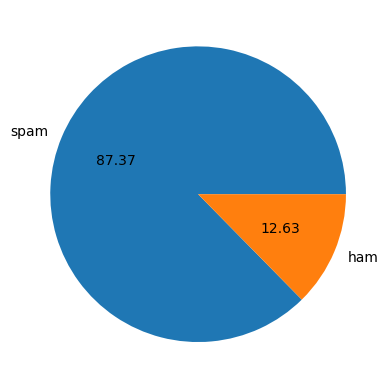

In [240]:
plt.pie(df["label"].value_counts(),labels=["spam","ham"],autopct='%0.2f')
plt.show()

### Feature enginering

In [241]:
import nltk

### num of character

In [242]:
df["num_character"] = df["text_combined"].apply(len)

### number of words

In [243]:
df["num_words"] = df["text_combined"].apply(lambda x: len(nltk.word_tokenize(x)))

In [244]:
df.head()

,label,text_combined,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


### number of sentences

In [245]:
df["num_sent"] = df["text_combined"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [246]:
df.head()

,label,text_combined,num_character,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [247]:
df.describe()

,label,num_character,num_words,num_sent
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


<Axes: xlabel='num_character', ylabel='Count'>

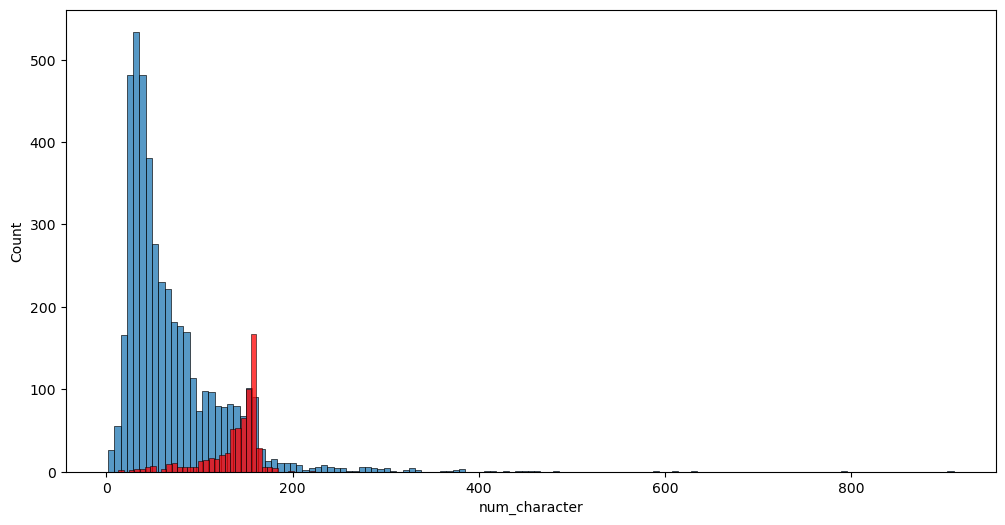

In [248]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label'] == 0]['num_character'])
sns.histplot(df[df['label'] == 1]['num_character'],color='red')

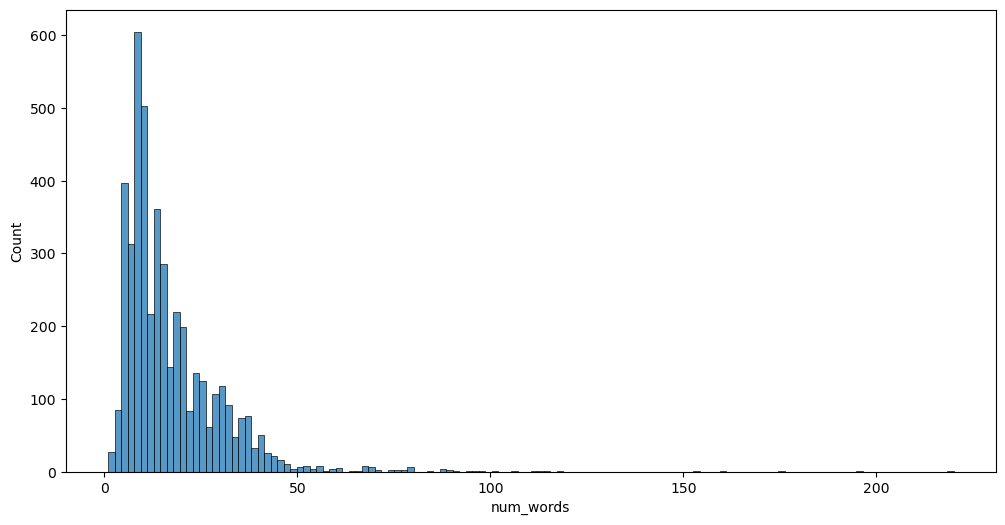

In [249]:
plt.figure(figsize =(12,6))
sns.histplot(df[df["label"]==0]["num_words"])
plt.show()

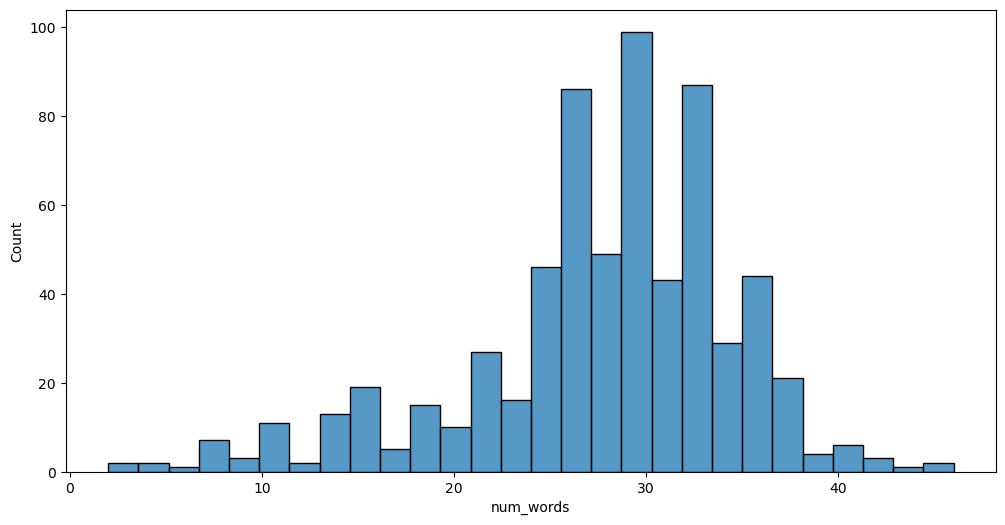

In [250]:
plt.figure(figsize =(12,6))
sns.histplot(df[df["label"]==1]["num_words"])
plt.show()

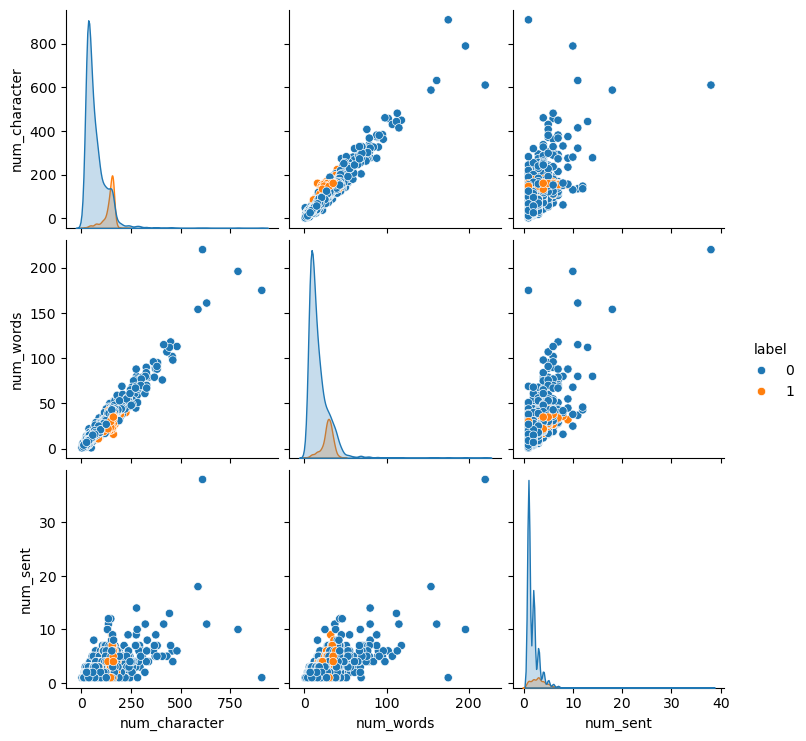

In [251]:
sns.pairplot(df,hue='label')

<Axes: >

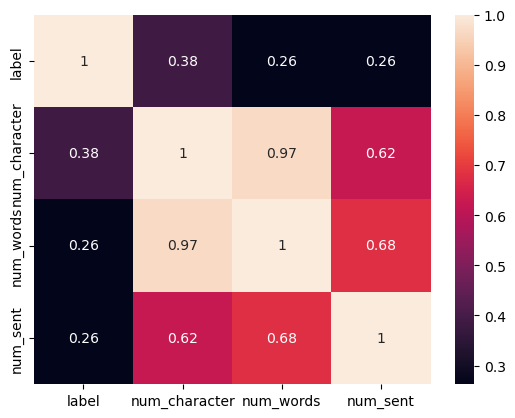

In [252]:
sns.heatmap(df.corr(numeric_only = True),annot=True)

In [253]:
df.head()

,label,text_combined,num_character,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


### Text preprocessing
- lowercase
- remove sepical character
- remove stopwords and punciation
- stemming

In [254]:
ps = PorterStemmer()

In [255]:
def transform_text(text_combined):
    text_combined = text_combined.lower()
    text_combined = nltk.word_tokenize(text_combined)
    y = []
    for i in text_combined:
        if i.isalnum():
            y.append(i)
    text_combined = y[:]
    y.clear()
    for i in text_combined:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text_combined = y[:]
    y.clear()
    for i in text_combined:
        y.append(ps.stem(i))
    return y

In [256]:
transform_text("How are you?? good learning ML i loved")

['good', 'learn', 'ml', 'love']

In [257]:
df['transformed_text'] = df["text_combined"].apply(transform_text)

In [258]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [259]:
spam_wc = wc.generate(df[df['label'] == 1]['transformed_text'].str.cat(sep=" "))

TypeError: Cannot use .str.cat with values of inferred dtype 'mixed'.

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [ ]:
ham_wc = wc.generate(df[df['label'] == 0]['transformed_text'].str.cat(sep=" "))

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [ ]:
df.head()

### Spam sum and most repeat words

In [ ]:
spam_corpus = []
for msg in df[df['label'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [ ]:
len(spam_corpus)

In [ ]:
most_common = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=most_common[0], y=most_common[1])
plt.xticks(rotation="vertical")
plt.show()

### Ham sum and most repeat words

In [ ]:
ham_corpus = []
for msg in df[df['label'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [ ]:
most_common1 = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=most_common[0], y=most_common[1])
plt.xticks(rotation="vertical")
plt.show()

### Count vectorizer

In [ ]:
cv = CountVectorizer
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df["transformed_text"]).toarray()

In [ ]:
y = df["label"].values

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Model building

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

### Gaussian Nb

In [ ]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

### Multinomial Nb

In [ ]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

### Bernoulli NB

In [ ]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

### Going with Multinomial NB

### Trying other algorithm

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [ ]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [ ]:
performance_df

In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")